In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [9]:
plt.style.use('/home/joliveira/Documents/franck-hertz/joao.mplstyle')
# --- DEFINIÇÃO DO TEMA GLOBAL USANDO rcParams ---
plt.rcParams['figure.figsize'] = (20, 12) # Define o tamanho da figura para 10x6 polegadas
plt.rcParams['font.size'] = 14           # Define o tamanho da fonte geral como 14
plt.rcParams['axes.titlesize'] = 25      # Tamanho da fonte do título
plt.rcParams['axes.labelsize'] = 20      # Tamanho da fonte dos rótulos dos eixos
plt.rcParams['axes.grid'] = True        # Habilita/desabilita a grade em todos os gráficos
plt.rcParams['grid.linestyle'] = '-'      # Estilo da grade: tracejado
plt.rcParams['grid.alpha'] = 0.6         # Transparência da grade
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['savefig.dpi'] = 700        # Alta resolução para salvar as figuras
plt.rcParams['lines.linestyle'] = '-'    # Linha sólida
plt.rcParams['lines.linewidth'] = 3   # Espessura da linha
# plt.rcParams['figure.facecolor'] = 'none'   # Fundo da figura transparente
# plt.rcParams['axes.facecolor']   = 'none'   # Fundo dos eixos transparente
# plt.rcParams['savefig.facecolor'] = 'none'  # Ao salvar, mantém transparente
# plt.rcParams['savefig.transparent'] = True  # Salva figuras com fundo transparente
plt.rcParams['xtick.labelsize'] = 16    # Tamanho dos rótulos do eixo x
plt.rcParams['ytick.labelsize'] = 16    # Tamanho dos rótulos do eixo y
# ---------------------------------------------------

Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 617 ('view raw')
Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 618 ('matplotlibrc hosted with ❤ by GitHub')


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import find_peaks

def plot_unica_excitacao(
    temperatura,
    pasta_dados,
    pasta_excel,
    salvar=False,
    pasta_saida=None
):
    # --- Montagem dos caminhos ---
    nome_txt = f"m1-u-e-T_{temperatura}.txt"
    nome_excel = f"Medidas Unica Excitações {temperatura}°C (Com fator de escala).xlsx"
    
    caminho_dados = os.path.join(pasta_dados, nome_txt)
    caminho_excel = os.path.join(pasta_excel, nome_excel)

    # --- Leitura do Excel ---
    try:
        df_excel = pd.read_excel(caminho_excel)
    except FileNotFoundError:
        print(f"❌ Arquivo Excel não encontrado: {caminho_excel}")
        return
    except Exception as e:
        print(f"❌ Erro ao ler Excel: {e}")
        return

    # --- Leitura do arquivo de dados ---
    try:
        df_dados = pd.read_csv(caminho_dados, sep=r"\s+", header=None, names=["Potencial (V)", "Corrente (A)"])
    except FileNotFoundError:
        print(f"❌ Arquivo de dados não encontrado: {caminho_dados}")
        return
    except Exception as e:
        print(f"❌ Erro ao ler dados: {e}")
        return

    # --- Obter fator de escala ---
    if "Escala " not in df_excel.columns:
        print("❌ Coluna 'Escala ' não encontrada no Excel.")
        print(f"Colunas disponíveis: {df_excel.columns.tolist()}")
        return

    fator_escala = df_excel["Escala "].iloc[0]
    print(f"📏 Fator de escala encontrado: {fator_escala:.3e}")

    # --- Aplicar fator de escala ---
    df_dados["Corrente Corrigida (A)"] = df_dados["Corrente (A)"] * fator_escala

    # --- Normalizar (max-min) ---
    corrente = df_dados["Corrente Corrigida (A)"]
    corrente_norm = (corrente - corrente.min()) / (corrente.max() - corrente.min())

    # --- Encontrar picos ---
    indices_picos, _ = find_peaks(corrente_norm, prominence=0.05)

    # --- Plot ---
    x = df_dados["Potencial (V)"]
    plt.plot(
        x,
        corrente_norm,
        color="red",
        linewidth=1.8,
        marker="o",
        markevery=25,
        markerfacecolor="red",
        # markeredgecolor="black",
        label="Corrente normalizada"
    )

    # --- Marcar picos (estrela vermelha com borda preta) ---
    plt.scatter(
        x.iloc[indices_picos],
        corrente_norm.iloc[indices_picos],
        color="white",
        edgecolor="black",
        marker="D",
        s=80,
        zorder=5,
        label="Picos detectados"
    )

    # --- Anotação do valor máximo (sem seta, canto superior esquerdo) ---
    valor_original_max = corrente.max()
    plt.text(
        0.02, 0.95,
        f"Corrente máxima: {valor_original_max:.2e} (A)",
        transform=plt.gca().transAxes,
        fontsize=20,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
    )

    # --- Personalização do gráfico ---
    plt.title(f"Curva de Única Excitação — {temperatura}°C")
    plt.xlabel("Potencial (V)")
    plt.ylabel("Corrente Normalizada")
    plt.grid(True, linestyle="-", alpha=0.5)
    plt.legend()

    # --- Salvar ou exibir ---
    if salvar and pasta_saida:
        os.makedirs(pasta_saida, exist_ok=True)
        caminho_saida = os.path.join(pasta_saida, f"Unica_Excitacao_{temperatura}C.png")
        plt.savefig(caminho_saida, dpi=300, bbox_inches="tight")
        print(f"✅ Gráfico salvo em: {caminho_saida}")
        plt.show()
        plt.close()
    else:
        plt.show()


📏 Fator de escala encontrado: 1.000e-07
✅ Gráfico salvo em: /home/joliveira/Documents/franck-hertz/Resultados/Unica_Excitacao_120C.png


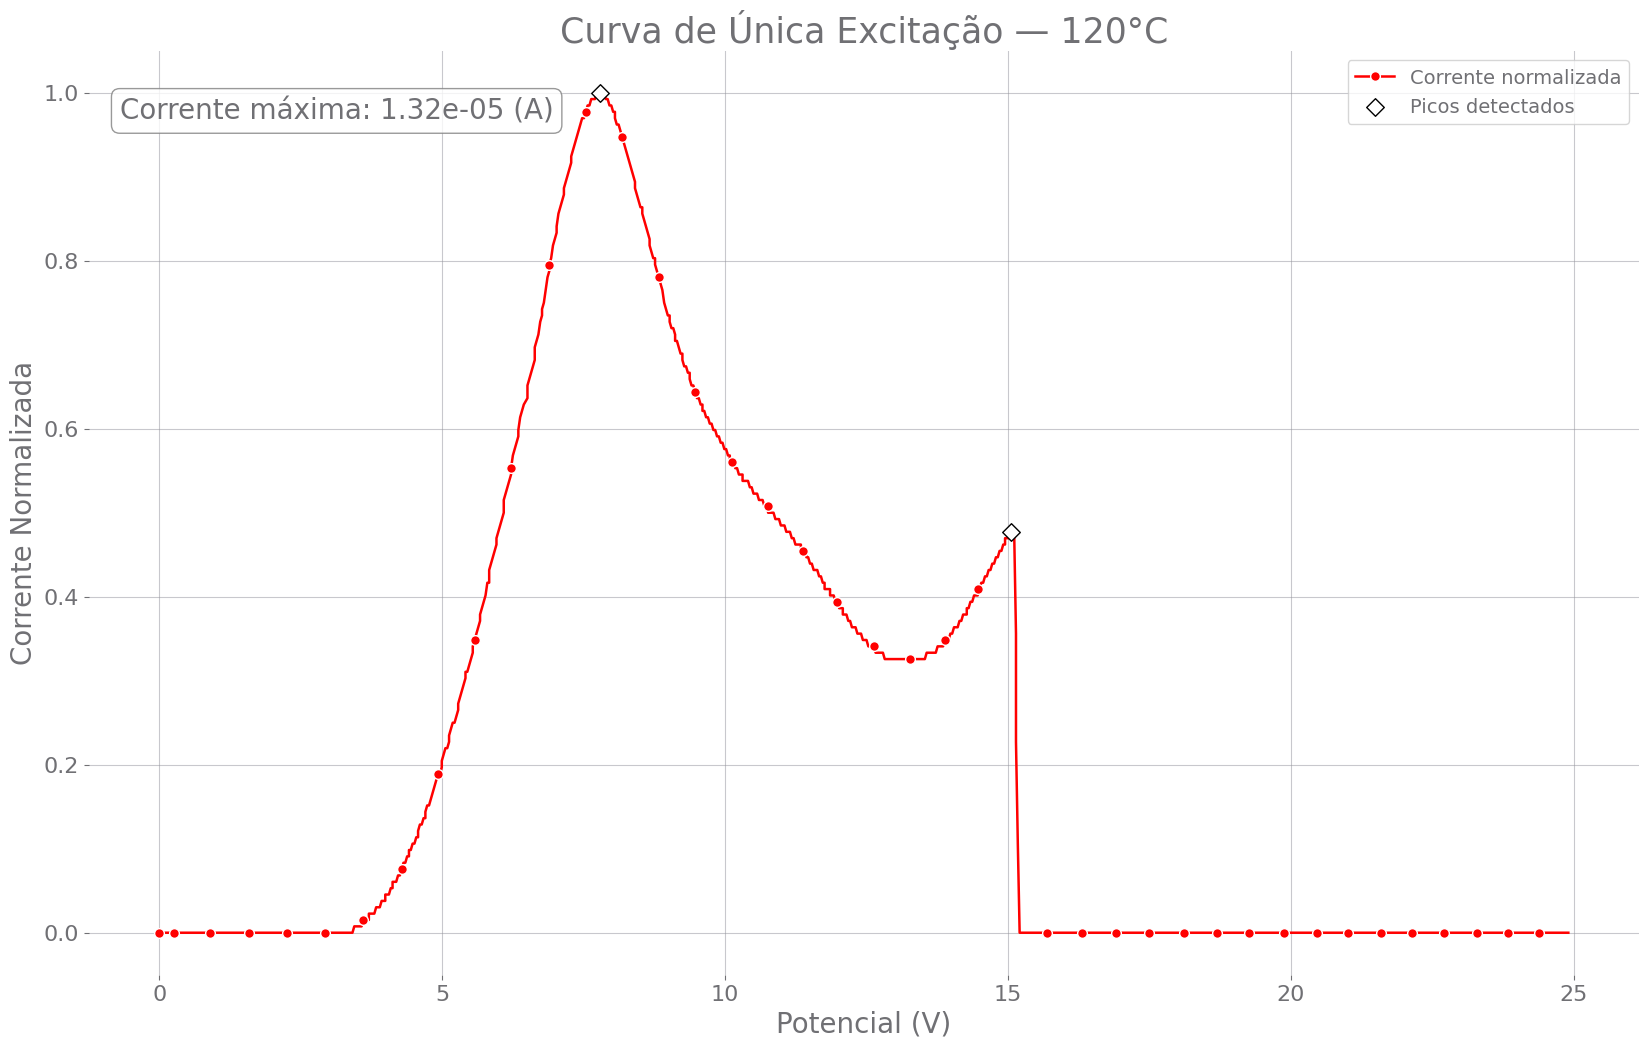

In [11]:
plot_unica_excitacao(
    temperatura=120,
    pasta_dados="Dados experimentais 23.10.2025 (Com fator de escala)/",
    pasta_excel="/home/joliveira/Documents/franck-hertz/",
    salvar=True,
    pasta_saida="/home/joliveira/Documents/franck-hertz/Resultados/"
)


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import find_peaks

def plot_multiplas_temperaturas(
    temperaturas,
    pasta_dados,
    pasta_excel,
    salvar=False,
    pasta_saida=None,
    log=True
):

    for temperatura in temperaturas:
        # --- Montagem dos caminhos ---
        nome_txt = f"m1-u-e-T_{temperatura}.txt"
        nome_excel = f"Medidas Unica Excitações {temperatura}°C (Com fator de escala).xlsx"
        caminho_dados = os.path.join(pasta_dados, nome_txt)
        caminho_excel = os.path.join(pasta_excel, nome_excel)

        # --- Leitura do Excel ---
        try:
            df_excel = pd.read_excel(caminho_excel)
        except FileNotFoundError:
            print(f"❌ Excel não encontrado: {caminho_excel}")
            continue
        except Exception as e:
            print(f"❌ Erro ao ler Excel ({temperatura}°C): {e}")
            continue

        # --- Leitura dos dados ---
        try:
            df_dados = pd.read_csv(caminho_dados, sep=r"\s+", header=None, names=["Potencial (V)", "Corrente (A)"])
        except FileNotFoundError:
            print(f"❌ Dados não encontrados: {caminho_dados}")
            continue
        except Exception as e:
            print(f"❌ Erro ao ler dados ({temperatura}°C): {e}")
            continue

        # --- Obter fator de escala ---
        if "Escala " not in df_excel.columns:
            print(f"❌ Coluna 'Escala ' não encontrada para {temperatura}°C.")
            continue

        fator_escala = df_excel["Escala "].iloc[0]

        # --- Corrigir corrente ---
        df_dados["Corrente Corrigida (A)"] = df_dados["Corrente (A)"] * fator_escala

        # --- Encontrar picos (em escala real, não normalizada) ---
        corrente = df_dados["Corrente Corrigida (A)"]
        x = df_dados["Potencial (V)"]

        # parâmetros ajustáveis para detecção de picos
        indices_picos, _ = find_peaks(corrente, prominence=np.max(corrente)*0.02)

        # --- Plot ---
        plt.plot(
            x,
            corrente,
            linewidth=1.6,
            marker="o",
            markevery=25,
            label=f"{temperatura}°C"
        )

        # --- Marcar e anotar pico ---
        if len(indices_picos) > 0:
            pico_idx = indices_picos[np.argmax(corrente.iloc[indices_picos])]
            x_pico = x.iloc[pico_idx]
            y_pico = corrente.iloc[pico_idx]
            
            plt.scatter(x_pico, y_pico, color="white", edgecolor="black", marker="D", s=80, zorder=5)
            plt.text(
                x_pico,
                y_pico * 1.1,
                f"{y_pico:.2e} A",
                fontsize=10,
                ha="center",
                va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.7)
            )

    # --- Configurações gerais ---
    plt.title("Curvas de Única Excitação — 120°C a 160°C")
    plt.xlabel("Potencial (V)")
    plt.ylabel("Corrente (A)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Temperatura")
    # plt.ylim(1e-8)
    # plt.xlim((0,14))
    # Escala logarítmica opcional
    if log:
        plt.yscale("log")

    # --- Salvar ou exibir ---
    if salvar and pasta_saida:
        os.makedirs(pasta_saida, exist_ok=True)
        caminho_saida = os.path.join(pasta_saida, "Unica_Excitacao_Todas.png")
        plt.savefig(caminho_saida, dpi=300, bbox_inches="tight")
        print(f"✅ Gráfico salvo em: {caminho_saida}")
        plt.show()
        plt.close()
    else:
        plt.show()


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import find_peaks
from adjustText import adjust_text

def plot_multiplas_temperaturas(
    temperaturas,
    pasta_dados,
    pasta_excel,
    salvar=False,
    pasta_saida=None,
    log=True
):

    textos = []  # lista de anotações para ajustar depois

    for temperatura in temperaturas:
        # --- Montagem dos caminhos ---
        nome_txt = f"m1-u-e-T_{temperatura}.txt"
        nome_excel = f"Medidas Unica Excitações {temperatura}°C (Com fator de escala).xlsx"
        caminho_dados = os.path.join(pasta_dados, nome_txt)
        caminho_excel = os.path.join(pasta_excel, nome_excel)

        # --- Leitura dos arquivos ---
        try:
            df_excel = pd.read_excel(caminho_excel)
            df_dados = pd.read_csv(caminho_dados, sep=r"\s+", header=None, names=["Potencial (V)", "Corrente (A)"])
        except Exception as e:
            print(f"⚠️ Erro ao ler dados para {temperatura}°C: {e}")
            continue

        # --- Obter fator de escala ---
        if "Escala " not in df_excel.columns:
            print(f"❌ Coluna 'Escala ' não encontrada para {temperatura}°C.")
            continue

        fator_escala = df_excel["Escala "].iloc[0]
        df_dados["Corrente Corrigida (A)"] = df_dados["Corrente (A)"] * fator_escala

        # --- Dados principais ---
        x = df_dados["Potencial (V)"]
        corrente = df_dados["Corrente Corrigida (A)"]

        # --- Encontrar picos ---
        indices_picos, _ = find_peaks(corrente, prominence=np.max(corrente)*0.02)

        # --- Plot principal ---
        plt.plot(
            x,
            corrente,
            linewidth=1.6,
            marker="o",
            markevery=25,
            label=f"{temperatura}°C"
        )

        # --- Anotar pico principal ---
        if len(indices_picos) > 0:
            pico_idx = indices_picos[np.argmax(corrente.iloc[indices_picos])]
            x_pico = x.iloc[pico_idx]
            y_pico = corrente.iloc[pico_idx]

            plt.scatter(x_pico, y_pico, color="white", edgecolor="black", marker="D", s=80, zorder=5)

            # deslocamento vertical proporcional à altura do pico
            desloc = y_pico * (0.3 if log else 0.05)

        #     txt = plt.text(
        #         x_pico,
        #         y_pico + desloc,
        #         f"{y_pico:.2e} A",
        #         fontsize=10,
        #         ha="center",
        #         va="bottom",
        #         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
        #     )
        #     textos.append(txt)

    # --- Ajuste automático (com mais força e liberdade) ---
    adjust_text(
        textos,
        only_move={'points': 'y', 'texts': 'xy'},
        force_text=30.0,        # mais força de repulsão
        force_points=4,
        expand_text=(1.3, 1.5),
        expand_points=(1.1, 1.4),
        arrowprops=None,
        avoid_points=True
    )

    # --- Configurações gerais ---
    plt.title("Curvas de Única Excitação — 120°C a 160°C", pad=30)
    plt.xlabel("Potencial (V)")
    plt.ylabel("Corrente (A)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Temperatura")

    if log:
        plt.yscale("log")

    # --- Salvar ou exibir ---
    if salvar and pasta_saida:
        os.makedirs(pasta_saida, exist_ok=True)
        caminho_saida = os.path.join(pasta_saida, "Unica_Excitacao_Todas.png")
        plt.savefig(caminho_saida, dpi=300, bbox_inches="tight")
        print(f"✅ Gráfico salvo em: {caminho_saida}")
        plt.show()
        plt.close()
    else:
        plt.show()


✅ Gráfico salvo em: /home/joliveira/Documents/franck-hertz/Resultados/Unica_Excitacao_Todas.png


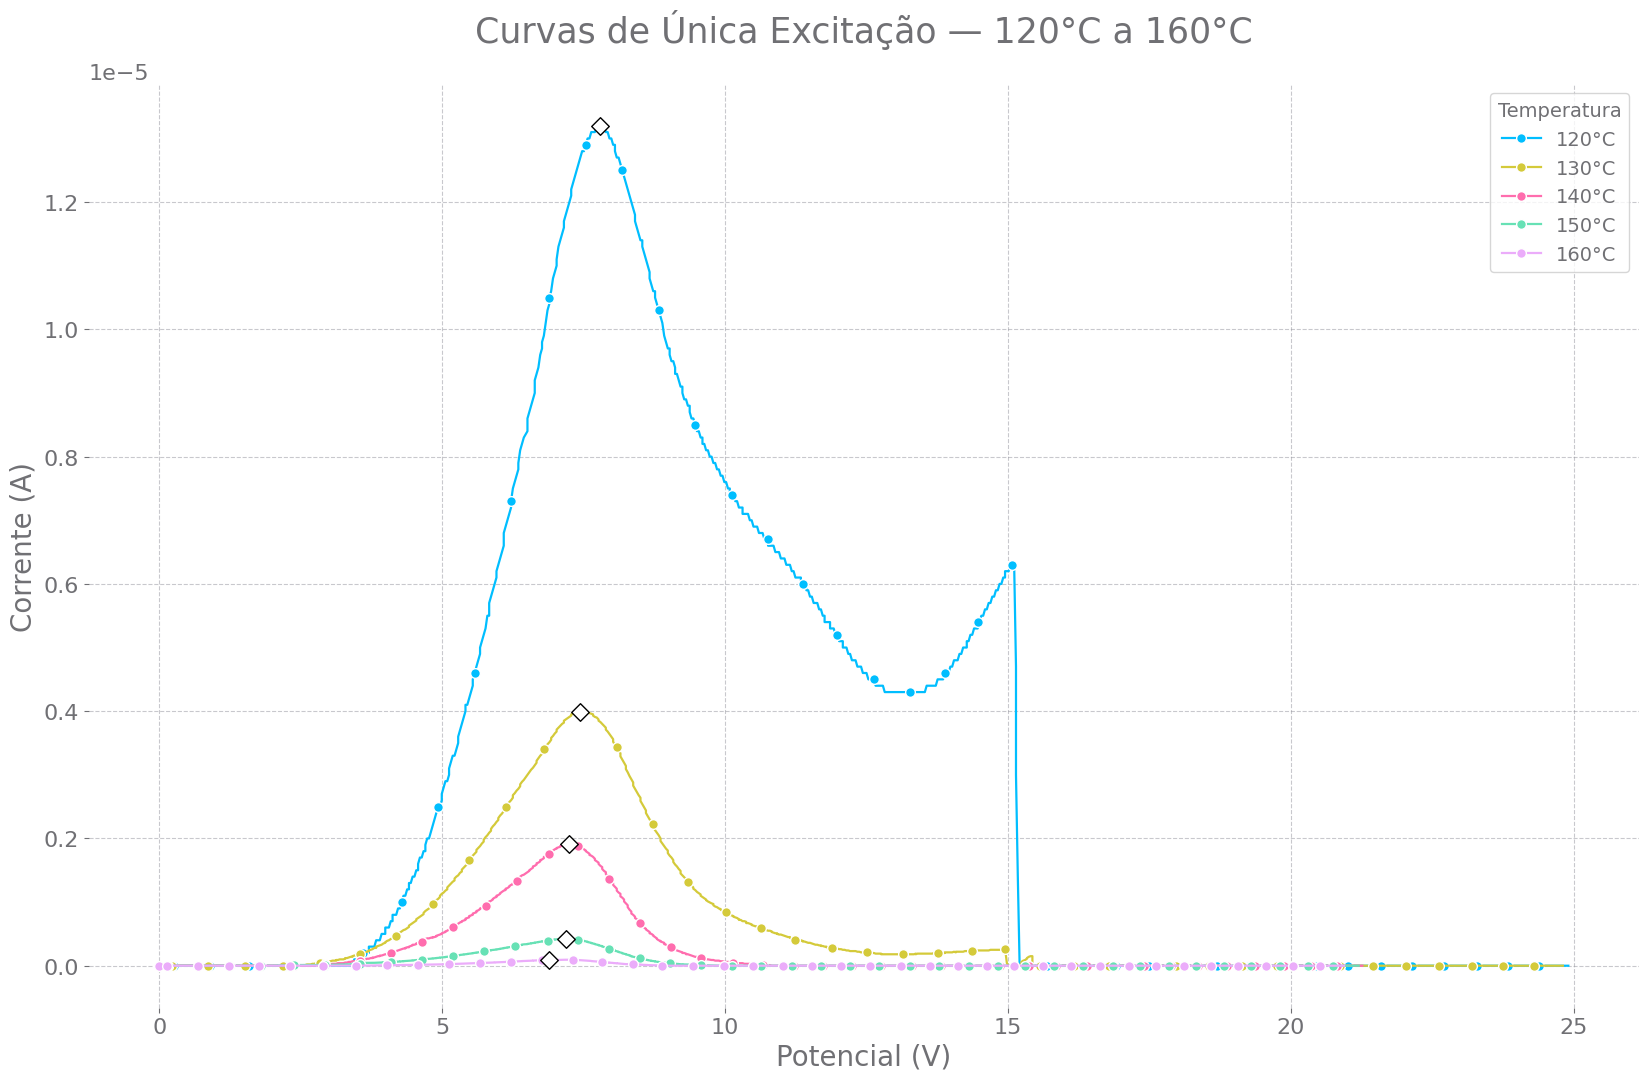

In [ ]:
plot_multiplas_temperaturas(
    temperaturas=[120, 130, 140, 150, 160],
    pasta_dados="Dados experimentais 23.10.2025 (Com fator de escala)/",
    pasta_excel="/home/joliveira/Documents/franck-hertz/",
    salvar=True,
    pasta_saida="/home/joliveira/Documents/franck-hertz/Resultados/",
    log=False
)

